In [1]:

# Importar librerías necesarias
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from pandas.tseries.holiday import USFederalHolidayCalendar
from google.colab import drive

# Montar Google Drive para acceder a los archivos
drive.mount('/content/drive')

# Definir la ruta base donde están los datasets
ruta_base = "/content/drive/My Drive/Maestria/ETL/Entrega_2/figuras/"
ruta_figuras = ruta_base + "figuras/"
os.makedirs(ruta_figuras, exist_ok=True)

# Opciones de visualización
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', 40)
sns.set_theme(style="whitegrid")

# Función auxiliar para guardar cada gráfica (se usarán en el informe PDF)
def guardar_figura(nombre):
    plt.savefig(ruta_figuras + nombre, dpi=150, bbox_inches="tight")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


--
# **1. Análisis Exploratorio de Datos (EDA)**

## **1.1 Carga y estructura de las fuentes**
Se cargan los tres archivos y se convierte la columna `Date`, que viene como texto en formato día/mes/año, a un tipo fecha real.

 **Extracción  – fuente primaria.**

In [2]:
# Ruta con el nombre de cada archivo csv en Google Drive
ruta_ventas = ruta_base + "sales data-set.csv"
ruta_features = ruta_base + "Features data set.csv"
ruta_tiendas = ruta_base + "stores data-set.csv"

# Leer los archivos CSV delimitados por ','
try:
    df_ventas = pd.read_csv(ruta_ventas, delimiter=",")
    df_features = pd.read_csv(ruta_features, delimiter=",")
    df_tiendas = pd.read_csv(ruta_tiendas, delimiter=",")
    print("Los tres archivos se cargaron correctamente.")
except FileNotFoundError as e:
    print("No se encontró alguno de los archivos:")
    print(e)

Los tres archivos se cargaron correctamente.


Mostramos las primeras filas de cada archivo para verificar que la carga fue exitosa:

In [3]:
print("### Ventas ###")
print(df_ventas.head(10))
print("\n### Features ###")
print(df_features.head(10))
print("\n### Tiendas ###")
print(df_tiendas.head(10))

### Ventas ###
   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  05/02/2010      24924.50      False
1      1     1  12/02/2010      46039.49       True
2      1     1  19/02/2010      41595.55      False
3      1     1  26/02/2010      19403.54      False
4      1     1  05/03/2010      21827.90      False
5      1     1  12/03/2010      21043.39      False
6      1     1  19/03/2010      22136.64      False
7      1     1  26/03/2010      26229.21      False
8      1     1  02/04/2010      57258.43      False
9      1     1  09/04/2010      42960.91      False

### Features ###
   Store        Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  Unemployment  IsHoliday
0      1  05/02/2010        42.31       2.572        NaN        NaN        NaN        NaN        NaN  211.096358         8.106      False
1      1  12/02/2010        38.51       2.548        NaN        NaN        NaN        NaN        NaN  211.242170       

Y vemos la estructura de cada DataFrame (tipos de datos y conteo de valores no nulos) con `info()`:

In [4]:
print("### Estructura de ventas ###")
df_ventas.info()
print("\n### Estructura de features ###")
df_features.info()
print("\n### Estructura de tiendas ###")
df_tiendas.info()

### Estructura de ventas ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB

### Estructura de features ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float6

Convertimos la columna Date a un tipo fecha real con `pd.to_datetime()`:

In [5]:
# Convertir la fecha (texto dd/mm/aaaa) a formato fecha
df_ventas["Date"] = pd.to_datetime(df_ventas["Date"], format="%d/%m/%Y")
df_features["Date"] = pd.to_datetime(df_features["Date"], format="%d/%m/%Y")

In [6]:
# Tabla resumen de la estructura de cada fuente
resumen_fuentes = pd.DataFrame({
    "Fuente": ["sales (ventas)", "features", "stores (tiendas)"],
    "Granularidad": ["semana x tienda x departamento", "semana x tienda", "tienda"],
    "Filas": [len(df_ventas), len(df_features), len(df_tiendas)],
    "Columnas": [df_ventas.shape[1], df_features.shape[1], df_tiendas.shape[1]],
    "Fecha_Inicio": [df_ventas["Date"].min().date(), df_features["Date"].min().date(), "N/A"],
    "Fecha_Fin": [df_ventas["Date"].max().date(), df_features["Date"].max().date(), "N/A"],
    "Semanas": [df_ventas["Date"].nunique(), df_features["Date"].nunique(), "N/A"]
})

print("### Estructura de las fuentes ###")
print(resumen_fuentes.to_string(index=False))

print("\nTiendas:", df_ventas["Store"].nunique(),
      "| Departamentos:", df_ventas["Dept"].nunique(),
      "| Combinaciones tienda-departamento:", df_ventas.groupby(["Store", "Dept"]).ngroups)
print("¿Todas las fechas son viernes?", (df_ventas["Date"].dt.dayofweek == 4).all())

### Estructura de las fuentes ###
          Fuente                   Granularidad  Filas  Columnas Fecha_Inicio  Fecha_Fin Semanas
  sales (ventas) semana x tienda x departamento 421570         5   2010-02-05 2012-10-26     143
        features                semana x tienda   8190        12   2010-02-05 2013-07-26     182
stores (tiendas)                         tienda     45         3          N/A        N/A     N/A

Tiendas: 45 | Departamentos: 81 | Combinaciones tienda-departamento: 3331
¿Todas las fechas son viernes? True


## **1.2 Estadísticas descriptivas de las ventas**
La variable principal es `Weekly_Sales`. Se revisa su distribución (media, mediana, percentiles y asimetría) y se compara por tipo de tienda.

In [7]:
# Estadísticas descriptivas de las ventas semanales
print("### Estadísticas de Weekly_Sales ###")
print(df_ventas["Weekly_Sales"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(2))
print("\nAsimetría (skew):", round(df_ventas["Weekly_Sales"].skew(), 2))

# Unir con las tiendas para comparar por tipo (A, B, C)
df_vt = df_ventas.merge(df_tiendas, on="Store", how="left")

print("\n### Ventas por tipo de tienda ###")
print(df_vt.groupby("Type")["Weekly_Sales"].agg(["count", "mean", "median", "std"]).round(2))

print("\n### Tiendas por tipo y tamaño ###")
print(df_tiendas.groupby("Type")["Size"].agg(["count", "mean", "min", "max"]).round(0))

# Departamentos con mayor participación en las ventas
participacion_dept = (df_ventas.groupby("Dept")["Weekly_Sales"].sum() / df_ventas["Weekly_Sales"].sum()).nlargest(5)
print("\n### Top 5 departamentos por participación en ventas ###")
print((participacion_dept * 100).round(1).astype(str) + " %")

### Estadísticas de Weekly_Sales ###
count    421570.00
mean      15981.26
std       22711.18
min       -4988.94
1%            5.00
5%           59.97
25%        2079.65
50%        7612.03
75%       20205.85
95%       61201.95
99%      106479.59
max      693099.36
Name: Weekly_Sales, dtype: float64

Asimetría (skew): 3.26

### Ventas por tipo de tienda ###
       count      mean    median       std
Type                                      
A     215478  20099.57  10105.17  26423.46
B     163495  12237.08   6187.87  17203.67
C      42597   9519.53   1149.67  15985.35

### Tiendas por tipo y tamaño ###
      count      mean    min     max
Type                                
A        22  177248.0  39690  219622
B        17  101191.0  34875  140167
C         6   40542.0  39690   42988

### Top 5 departamentos por participación en ventas ###
Dept
92    7.2 %
95    6.7 %
38    5.8 %
72    4.5 %
90    4.3 %
Name: Weekly_Sales, dtype: object


## **1.3 Distribución de las ventas**
Se compara la distribución original de `Weekly_Sales` con su versión en escala logarítmica. Si la gráfica original tiene una cola larga a la derecha, el logaritmo ayuda a que los datos sean más simétricos.

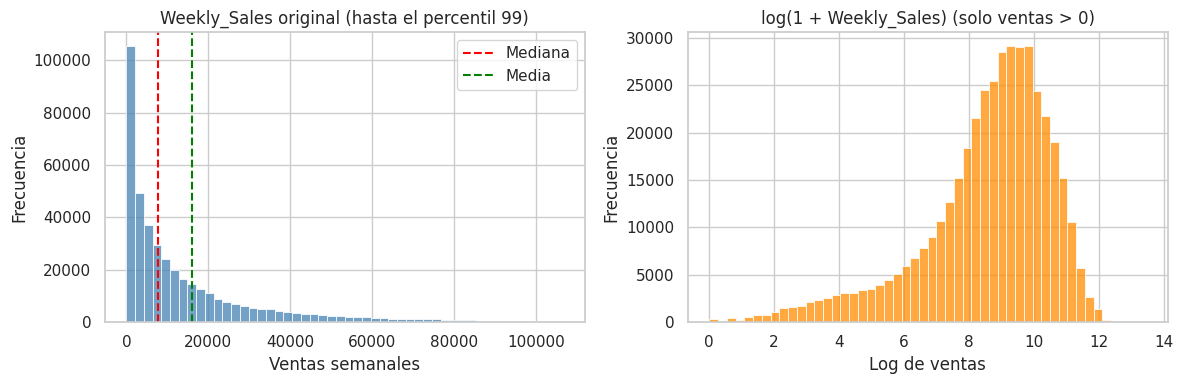

In [8]:
# Figura 1: distribución de ventas (original vs logarítmica)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Se recorta en el percentil 99 solo para poder ver la forma de la distribución
p99_ventas = df_ventas["Weekly_Sales"].quantile(0.99)
ventas_visibles = df_ventas.loc[df_ventas["Weekly_Sales"].between(0, p99_ventas), "Weekly_Sales"]

sns.histplot(ventas_visibles, bins=50, ax=axes[0], color="steelblue")
axes[0].axvline(df_ventas["Weekly_Sales"].median(), color="red", linestyle="--", label="Mediana")
axes[0].axvline(df_ventas["Weekly_Sales"].mean(), color="green", linestyle="--", label="Media")
axes[0].set_title("Weekly_Sales original (hasta el percentil 99)")
axes[0].set_xlabel("Ventas semanales")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

sns.histplot(np.log1p(df_ventas.loc[df_ventas["Weekly_Sales"] > 0, "Weekly_Sales"]), bins=50, ax=axes[1], color="darkorange")
axes[1].set_title("log(1 + Weekly_Sales) (solo ventas > 0)")
axes[1].set_xlabel("Log de ventas")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
guardar_figura("fig1_distribucion_ventas.png")
plt.show()

## **1.4 Patrones temporales: estacionalidad y festivos**
Se suman las ventas de todas las tiendas por semana para ver la tendencia a lo largo del tiempo. Las líneas rojas son las semanas que el dataset marca como festivo (`IsHoliday`) y los puntos naranja son las dos semanas con más ventas.

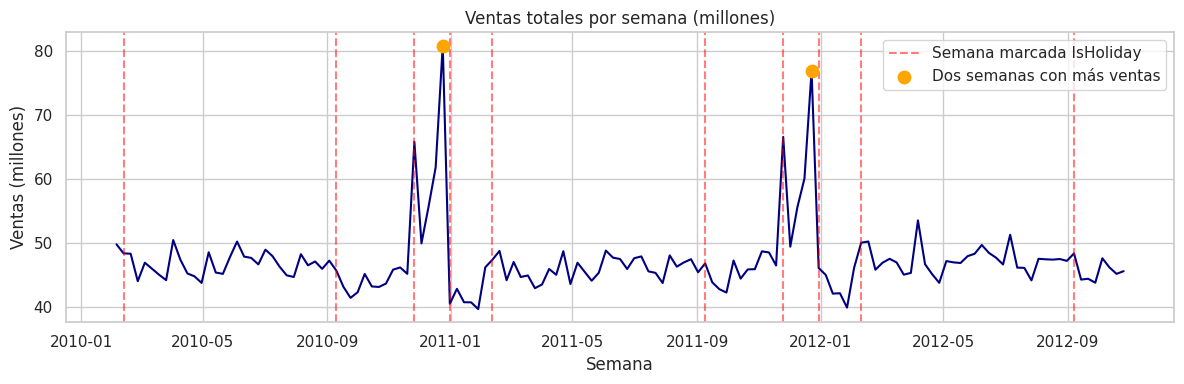

Semanas marcadas como festivo: ['2010-02-12', '2010-09-10', '2010-11-26', '2010-12-31', '2011-02-11', '2011-09-09', '2011-11-25', '2011-12-30', '2012-02-10', '2012-09-07']

Dos semanas con más ventas (millones):
Date
2010-12-24    80.9
2011-12-23    77.0
Name: Weekly_Sales, dtype: float64


In [9]:
# Ventas totales por semana (en millones)
ventas_semana = df_ventas.groupby("Date")["Weekly_Sales"].sum() / 1e6
semanas_festivo = sorted(df_ventas.loc[df_ventas["IsHoliday"], "Date"].unique())
top2 = ventas_semana.nlargest(2)

# Figura 2: serie de tiempo con festivos marcados
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ventas_semana.index, ventas_semana.values, color="navy", linewidth=1.5)
for i, semana in enumerate(semanas_festivo):
    ax.axvline(semana, color="red", linestyle="--", alpha=0.5, label="Semana marcada IsHoliday" if i == 0 else None)
ax.scatter(top2.index, top2.values, color="orange", s=80, zorder=5, label="Dos semanas con más ventas")
ax.set_title("Ventas totales por semana (millones)")
ax.set_xlabel("Semana")
ax.set_ylabel("Ventas (millones)")
ax.legend()

plt.tight_layout()
guardar_figura("fig2_serie_semanal.png")
plt.show()

print("Semanas marcadas como festivo:", [pd.Timestamp(s).date().isoformat() for s in semanas_festivo])
print("\nDos semanas con más ventas (millones):")
print(top2.round(1))

## **1.5 Relaciones entre variables**
Se revisa si el tamaño de la tienda se relaciona con las ventas y qué variables externas (clima, combustible, descuentos, IPC, desempleo) se parecen más a las ventas.

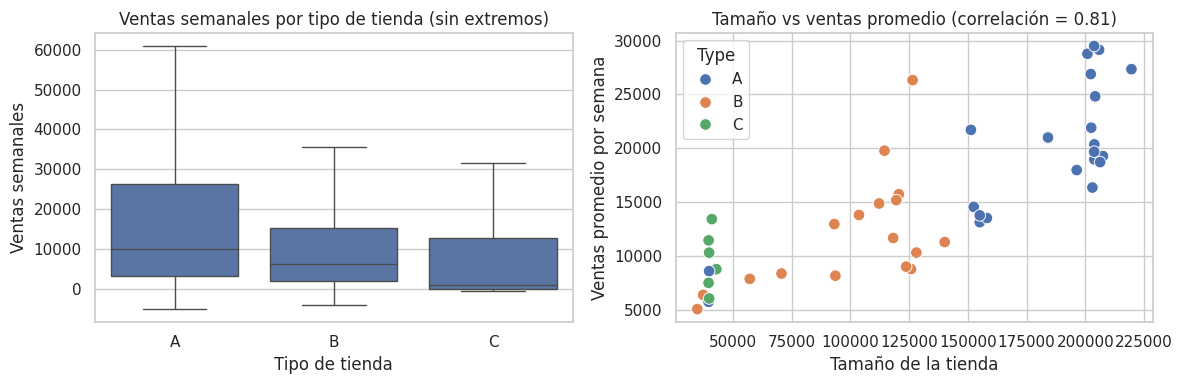

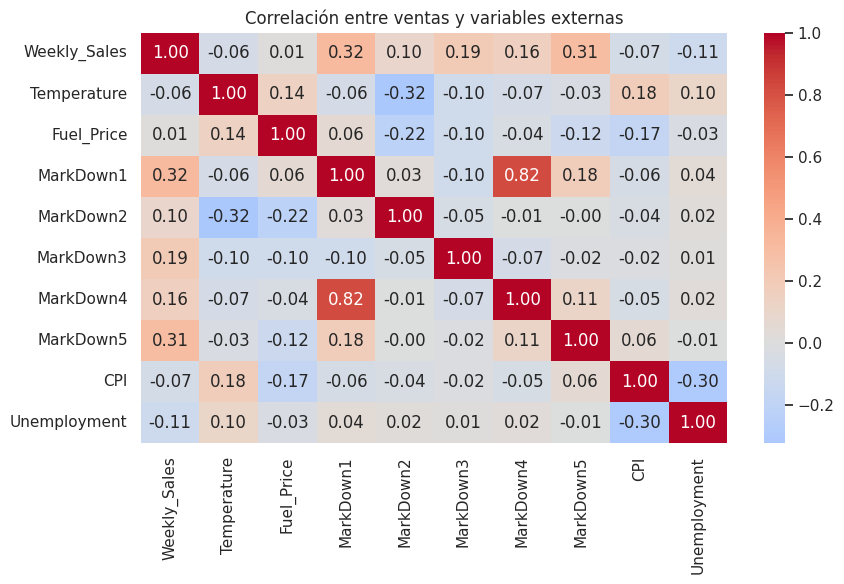

Correlación tamaño de tienda vs ventas promedio: 0.81

Nota: las correlaciones de MarkDown usan solo las semanas donde hay dato (desde noviembre de 2011).


In [10]:
# Ventas promedio por tienda para compararlas con su tamaño
ventas_tienda = df_vt.groupby(["Store", "Type", "Size"])["Weekly_Sales"].mean().reset_index()
corr_size = ventas_tienda["Size"].corr(ventas_tienda["Weekly_Sales"])

# Ventas totales por tienda y semana, unidas con las variables externas
ventas_tienda_semana = df_ventas.groupby(["Store", "Date"])["Weekly_Sales"].sum().reset_index()
df_corr = ventas_tienda_semana.merge(df_features, on=["Store", "Date"], how="left")
cols_corr = ["Weekly_Sales", "Temperature", "Fuel_Price", "MarkDown1", "MarkDown2",
             "MarkDown3", "MarkDown4", "MarkDown5", "CPI", "Unemployment"]

# Figura 3: ventas por tipo de tienda y tamaño vs ventas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df_vt, x="Type", y="Weekly_Sales", order=["A", "B", "C"], showfliers=False, ax=axes[0])
axes[0].set_title("Ventas semanales por tipo de tienda (sin extremos)")
axes[0].set_xlabel("Tipo de tienda")
axes[0].set_ylabel("Ventas semanales")

sns.scatterplot(data=ventas_tienda, x="Size", y="Weekly_Sales", hue="Type", hue_order=["A", "B", "C"], s=70, ax=axes[1])
axes[1].set_title(f"Tamaño vs ventas promedio (correlación = {corr_size:.2f})")
axes[1].set_xlabel("Tamaño de la tienda")
axes[1].set_ylabel("Ventas promedio por semana")

plt.tight_layout()
guardar_figura("fig3_tipo_tamano.png")
plt.show()

# Figura 4: correlación entre ventas y variables externas
plt.figure(figsize=(9, 6))
sns.heatmap(df_corr[cols_corr].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlación entre ventas y variables externas")
plt.tight_layout()
guardar_figura("fig4_correlacion.png")
plt.show()

print("Correlación tamaño de tienda vs ventas promedio:", round(corr_size, 2))
print("\nNota: las correlaciones de MarkDown usan solo las semanas donde hay dato (desde noviembre de 2011).")

### **Hallazgos clave del EDA**
1. Las ventas tienen una cola larga hacia la derecha: la media es muy superior a la mediana y la asimetría es alta.
2. Existen ventas negativas y ceros (se cuantifican en la sección 2).
3. Las semanas de mayores ventas son las **previas a Navidad**, y esas semanas **no están marcadas** como festivo en `IsHoliday`.
4. El tamaño de la tienda se relaciona fuertemente con sus ventas, y las tiendas tipo C venden mucho menos por unidad de tamaño.
5. Los descuentos (MarkDown) tienen la mayor relación con las ventas; temperatura, combustible, IPC y desempleo tienen relación débil.

# **2. Análisis de Calidad de los Datos (modelo de las V's)**

## **2.1 Valores nulos**

### Nulos en Features ###
              Nulos  Porcentaje
MarkDown1      4158        50.8
MarkDown2      5269        64.3
MarkDown3      4577        55.9
MarkDown4      4726        57.7
MarkDown5      4140        50.5
CPI             585         7.1
Unemployment    585         7.1

Nulos en Ventas: 0 | Nulos en Tiendas: 0


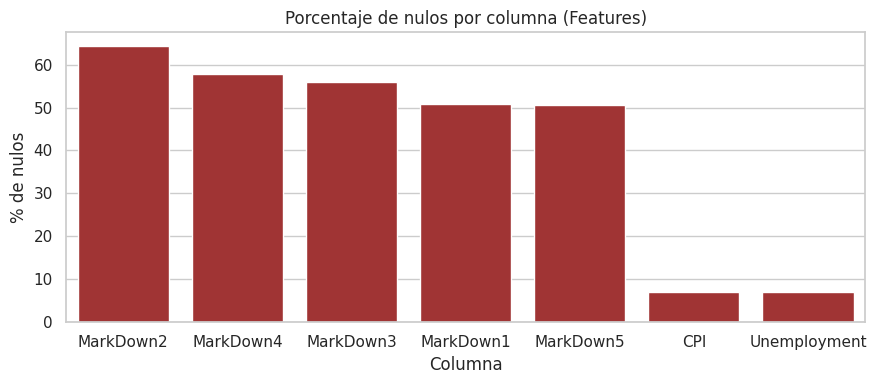

In [11]:
# Nulos en Features (las otras dos fuentes no tienen nulos)
nulos = pd.DataFrame({
    "Nulos": df_features.isnull().sum(),
    "Porcentaje": (df_features.isnull().mean() * 100).round(1)
})
print("### Nulos en Features ###")
print(nulos[nulos["Nulos"] > 0])
print("\nNulos en Ventas:", int(df_ventas.isnull().sum().sum()), "| Nulos en Tiendas:", int(df_tiendas.isnull().sum().sum()))

# Figura 5: porcentaje de nulos por columna
plt.figure(figsize=(9, 4))
nulos_graf = nulos[nulos["Nulos"] > 0]["Porcentaje"].sort_values(ascending=False)
sns.barplot(x=nulos_graf.index, y=nulos_graf.values, color="firebrick")
plt.title("Porcentaje de nulos por columna (Features)")
plt.xlabel("Columna")
plt.ylabel("% de nulos")
plt.tight_layout()
guardar_figura("fig5_nulos.png")
plt.show()

### **Nulos de los descuentos (MarkDown)**
Se revisa **desde cuándo** existen datos de descuentos y cuántos nulos quedan dentro del periodo que tiene ventas. Esto define cómo interpretar un nulo: "no se registraba" (antes de la fecha de inicio) o "no hubo descuento" (después).

In [12]:
cols_md = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]

# Primera fecha en la que aparece algún descuento
fecha_inicio_md = df_features.dropna(subset=cols_md, how="all")["Date"].min()
fecha_fin_ventas = df_ventas["Date"].max()
print("Primera fecha con datos de descuentos:", fecha_inicio_md.date())
print("Última fecha con ventas:", fecha_fin_ventas.date())

# Porcentaje de nulos antes y después de esa fecha (solo periodo con ventas)
feat_periodo = df_features[df_features["Date"] <= fecha_fin_ventas]
antes = feat_periodo[feat_periodo["Date"] < fecha_inicio_md][cols_md].isnull().mean() * 100
despues = feat_periodo[feat_periodo["Date"] >= fecha_inicio_md][cols_md].isnull().mean() * 100
print("\n### % de nulos en MarkDown (periodo con ventas) ###")
print(pd.DataFrame({"Antes_de_nov_2011": antes.round(1), "Desde_nov_2011": despues.round(1)}))

# Porcentaje de filas de ventas sin ningún descuento registrado
ventas_md = df_ventas.merge(df_features[["Store", "Date"] + cols_md], on=["Store", "Date"], how="left")
pct_md_sin_dato = ventas_md[cols_md].isnull().all(axis=1).mean()
print(f"\nFilas de ventas sin ningún MarkDown: {pct_md_sin_dato:.1%}")

# Valores negativos en los descuentos
md_negativos = int((df_features[cols_md] < 0).sum().sum())
print("Valores negativos en MarkDown:", md_negativos)

# Nulos de IPC y desempleo: ¿en qué fechas están?
fechas_cpi_nulo = df_features.loc[df_features["CPI"].isnull(), "Date"]
print("\nNulos de CPI/Unemployment entre", fechas_cpi_nulo.min().date(), "y", fechas_cpi_nulo.max().date())
print("Nulos de CPI dentro del periodo con ventas:", int(feat_periodo["CPI"].isnull().sum()))

Primera fecha con datos de descuentos: 2011-11-11
Última fecha con ventas: 2012-10-26

### % de nulos en MarkDown (periodo con ventas) ###
           Antes_de_nov_2011  Desde_nov_2011
MarkDown1              100.0             0.7
MarkDown2              100.0            28.7
MarkDown3              100.0            10.8
MarkDown4              100.0            14.4
MarkDown5              100.0             0.0

Filas de ventas sin ningún MarkDown: 64.1%
Valores negativos en MarkDown: 44

Nulos de CPI/Unemployment entre 2013-05-03 y 2013-07-26
Nulos de CPI dentro del periodo con ventas: 0


## **2.2 Ventas negativas, ceros y valores extremos**

In [13]:
n_negativas = int((df_ventas["Weekly_Sales"] < 0).sum())
n_ceros = int((df_ventas["Weekly_Sales"] == 0).sum())
suma_negativas = df_ventas.loc[df_ventas["Weekly_Sales"] < 0, "Weekly_Sales"].sum()

print(f"Ventas negativas: {n_negativas} ({n_negativas / len(df_ventas):.2%}) | mínimo = {df_ventas['Weekly_Sales'].min():,.2f}")
print(f"Ventas iguales a cero: {n_ceros}")
print(f"Suma de las negativas: {suma_negativas:,.0f} (frente a ventas totales de {df_ventas['Weekly_Sales'].sum():,.0f})")
print(f"Ventas de 100 o menos: {(df_ventas['Weekly_Sales'] <= 100).mean():.1%}")

print("\n### Departamentos con más ventas negativas ###")
print(df_ventas.loc[df_ventas["Weekly_Sales"] < 0, "Dept"].value_counts().head(5))

# Valores extremos: regla IQR y z-score por combinación tienda-departamento
q1, q3 = df_ventas["Weekly_Sales"].quantile([0.25, 0.75])
limite_sup = q3 + 1.5 * (q3 - q1)
n_iqr = int((df_ventas["Weekly_Sales"] > limite_sup).sum())

grupo = df_ventas.groupby(["Store", "Dept"])["Weekly_Sales"]
z_score = (df_ventas["Weekly_Sales"] - grupo.transform("mean")) / grupo.transform("std")
n_z3 = int((z_score.abs() > 3).sum())
print(f"\nExtremos altos por IQR (global): {n_iqr} ({n_iqr / len(df_ventas):.1%})")
print(f"Extremos por z-score > 3 (dentro de cada tienda-departamento): {n_z3} ({n_z3 / len(df_ventas):.1%})")

Ventas negativas: 1285 (0.30%) | mínimo = -4,988.94
Ventas iguales a cero: 73
Suma de las negativas: -88,162 (frente a ventas totales de 6,737,218,987)
Ventas de 100 o menos: 6.4%

### Departamentos con más ventas negativas ###
Dept
47    254
18    180
54    146
19     87
94     77
Name: count, dtype: int64

Extremos altos por IQR (global): 35521 (8.4%)
Extremos por z-score > 3 (dentro de cada tienda-departamento): 5945 (1.4%)


Top 10 departamentos por tasa de devoluciones
Dept
47    39.32 %
78    14.04 %
77    10.67 %
18     3.58 %
54     3.06 %
19     2.11 %
51     1.79 %
49     1.49 %
94     1.35 %
45     1.24 %
dtype: object

Monto devuelto por los 3 departamentos con más devoluciones:
  Depto 47: 254 devoluciones, suman -53,188
  Depto 18: 180 devoluciones, suman -1,819
  Depto 54: 146 devoluciones, suman -4,830


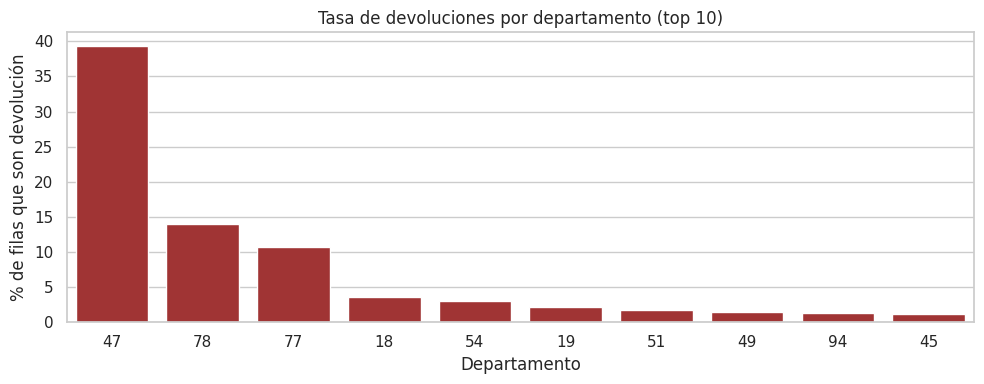

In [14]:
#Devoluciones
devoluciones = df_ventas[df_ventas["Weekly_Sales"] < 0].copy()

#devoluciones por fila
total_por_dept = df_ventas.groupby("Dept").size()
dev_por_dept = devoluciones.groupby("Dept").size()
tasa_dev = (dev_por_dept / total_por_dept * 100).sort_values(ascending=False).head(10)
print("Top 10 departamentos por tasa de devoluciones")
print(tasa_dev.round(2).astype(str) + " %")

#cuanto es en dinero las devoluciones
print("\nMonto devuelto por los 3 departamentos con más devoluciones:")
top3 = devoluciones["Dept"].value_counts().head(3).index
for d in top3:
    monto = devoluciones[devoluciones["Dept"] == d]["Weekly_Sales"].sum()
    n = (devoluciones["Dept"] == d).shape[0]
    print(f"  Depto {d}: {int((devoluciones['Dept']==d).sum())} devoluciones, suman {monto:,.0f}")

#tasa de devoluciones en los departamentos afectados
plt.figure(figsize=(10, 4))
sns.barplot(x=tasa_dev.index.astype(str), y=tasa_dev.values, color="firebrick")
plt.title("Tasa de devoluciones por departamento (top 10)")
plt.xlabel("Departamento")
plt.ylabel("% de filas que son devolución")
plt.tight_layout()
guardar_figura("fig8_devoluciones.png")
plt.show()

## **2.3 Filas faltantes en la cuadrícula tienda x departamento x semana**
Si cada combinación tienda-departamento tuviera todas las semanas, la tabla de ventas tendría más filas. Se calcula cuántas faltan y se separan en dos tipos: **huecos internos** (una semana desaparece en la mitad de la serie) y **huecos de borde** (la serie empieza tarde o termina antes).

In [15]:
# Resumen por combinación tienda-departamento
combos = df_ventas.groupby(["Store", "Dept"])["Date"].agg(["min", "max", "count"]).reset_index()
combos["Semanas_Esperadas"] = ((combos["max"] - combos["min"]).dt.days // 7) + 1
combos["Huecos_Internos"] = combos["Semanas_Esperadas"] - combos["count"]

n_semanas = df_ventas["Date"].nunique()
filas_ideales = len(combos) * n_semanas
filas_faltantes = filas_ideales - len(df_ventas)
huecos_internos = int(combos["Huecos_Internos"].sum())
huecos_borde = filas_faltantes - huecos_internos
combos_completos = int((combos["count"] == n_semanas).sum())
combos_cortos = int((combos["count"] < 52).sum())

print(f"Combinaciones tienda-departamento: {len(combos)}")
print(f"Filas si todas tuvieran {n_semanas} semanas: {filas_ideales:,} | filas reales: {len(df_ventas):,}")
print(f"Filas faltantes: {filas_faltantes:,} ({filas_faltantes / filas_ideales:.1%})")
print(f"   - Huecos internos (semanas que desaparecen en medio): {huecos_internos:,} en {(combos['Huecos_Internos'] > 0).sum()} combinaciones")
print(f"   - Huecos de borde (serie que empieza tarde o termina antes): {huecos_borde:,}")
print(f"Combinaciones completas: {combos_completos} | con menos de 52 semanas: {combos_cortos}")

Combinaciones tienda-departamento: 3331
Filas si todas tuvieran 143 semanas: 476,333 | filas reales: 421,570
Filas faltantes: 54,763 (11.5%)
   - Huecos internos (semanas que desaparecen en medio): 27,667 en 605 combinaciones
   - Huecos de borde (serie que empieza tarde o termina antes): 27,096
Combinaciones completas: 2660 | con menos de 52 semanas: 340


## **2.4 Consistencia, integridad y festivos**

In [16]:
# Duplicados y consistencia entre archivos
print("Duplicados en ventas (Store, Dept, Date):", int(df_ventas.duplicated(["Store", "Dept", "Date"]).sum()))
print("Duplicados en features (Store, Date):", int(df_features.duplicated(["Store", "Date"]).sum()))

comparacion = df_ventas.merge(df_features[["Store", "Date", "IsHoliday"]], on=["Store", "Date"], how="left", suffixes=("", "_feat"))
print("Ventas sin pareja en features:", int(comparacion["IsHoliday_feat"].isnull().sum()))
print("IsHoliday distinto entre ventas y features:", int((comparacion["IsHoliday"] != comparacion["IsHoliday_feat"]).sum()))
print("Tiendas que están en ventas pero no en el maestro:", len(set(df_ventas["Store"]) - set(df_tiendas["Store"])))

# ¿La marca IsHoliday coincide con las semanas de mayores ventas?
flag_semana = df_ventas.groupby("Date")["IsHoliday"].first()
mediana_semana = ventas_semana.median()
fechas_ref = pd.to_datetime(["2010-11-26", "2010-12-24", "2010-12-31", "2011-11-25", "2011-12-23", "2011-12-30"])
tabla_festivos = pd.DataFrame({
    "Semana": fechas_ref.date,
    "Ventas_millones": ventas_semana.loc[fechas_ref].round(1).values,
    "Veces_la_mediana": (ventas_semana.loc[fechas_ref] / mediana_semana).round(2).values,
    "Marcada_IsHoliday": flag_semana.loc[fechas_ref].values
})
print("\n### Semanas de Acción de Gracias y Navidad vs la marca IsHoliday ###")
print(tabla_festivos.to_string(index=False))

# Ventas promedio en semanas marcadas vs no marcadas
print("\n### Ventas promedio según IsHoliday ###")
print(df_ventas.groupby("IsHoliday")["Weekly_Sales"].agg(["count", "mean", "median"]).round(0))

# Temperatura: unidades
print("\nRango de Temperature:", df_features["Temperature"].min(), "a", df_features["Temperature"].max(), "(parece estar en grados Fahrenheit)")

Duplicados en ventas (Store, Dept, Date): 0
Duplicados en features (Store, Date): 0
Ventas sin pareja en features: 0
IsHoliday distinto entre ventas y features: 0
Tiendas que están en ventas pero no en el maestro: 0

### Semanas de Acción de Gracias y Navidad vs la marca IsHoliday ###
    Semana  Ventas_millones  Veces_la_mediana  Marcada_IsHoliday
2010-11-26             65.8              1.42               True
2010-12-24             80.9              1.75              False
2010-12-31             40.4              0.87               True
2011-11-25             66.6              1.44               True
2011-12-23             77.0              1.67              False
2011-12-30             46.0              1.00               True

### Ventas promedio según IsHoliday ###
            count     mean  median
IsHoliday                         
False      391909  15901.0  7590.0
True        29661  17036.0  7948.0

Rango de Temperature: -7.29 a 101.95 (parece estar en grados Fahrenheit)


## **2.5 Detección de registros anómalos**
Igual que en la práctica de detección de anómalos, se crea una columna booleana por cada tipo de anomalía y luego se filtran las filas donde alguna de ellas sea `True` (`any(axis=1)`).

Detectamos las anomalías en la tabla de ventas:

In [17]:
# Copia de las ventas para marcar las anomalías
df_anomalos = df_ventas.copy()

# 1. Ventas negativas (posibles devoluciones o ajustes)
df_anomalos["Venta_Negativa"] = df_anomalos["Weekly_Sales"] < 0

# 2. Ventas iguales a cero
df_anomalos["Venta_Cero"] = df_anomalos["Weekly_Sales"] == 0

# 3. Claves duplicadas (Store, Dept, Date)
df_anomalos["Clave_Duplicada"] = df_anomalos.duplicated(subset=["Store", "Dept", "Date"], keep=False)

# 4. Tiendas que no existen en el maestro de tiendas
df_anomalos["Tienda_Desconocida"] = ~df_anomalos["Store"].isin(df_tiendas["Store"])

# 5. Ventas sin fila de variables externas (Store + Date)
claves_features = set(zip(df_features["Store"], df_features["Date"]))
df_anomalos["Sin_Features"] = [(t, f) not in claves_features for t, f in zip(df_anomalos["Store"], df_anomalos["Date"])]

# 6. Fechas que no son viernes (todas las semanas del dataset terminan en viernes)
df_anomalos["Fecha_No_Viernes"] = df_anomalos["Date"].dt.dayofweek != 4

Contamos cuántas filas tiene cada anomalía, mostramos las filas con alguna anomalía y las guardamos en un archivo separado:

In [18]:
cols_anomalias = ["Venta_Negativa", "Venta_Cero", "Clave_Duplicada", "Tienda_Desconocida", "Sin_Features", "Fecha_No_Viernes"]

print("### Cantidad de registros por tipo de anomalía ###")
print(df_anomalos[cols_anomalias].sum())

# Mostrar las filas con anomalías
df_ventas_anomalias = df_anomalos[df_anomalos[cols_anomalias].any(axis=1)]
print(f"\nRegistros de ventas con alguna anomalía: {len(df_ventas_anomalias):,} de {len(df_ventas):,} ({len(df_ventas_anomalias) / len(df_ventas):.2%})")
print(df_ventas_anomalias.head())

# Guardar los datos anómalos en un archivo separado
df_ventas_anomalias.to_csv(ruta_base + "datos_anomalos_detectados.csv", index=False)

### Cantidad de registros por tipo de anomalía ###
Venta_Negativa        1285
Venta_Cero              73
Clave_Duplicada          0
Tienda_Desconocida       0
Sin_Features             0
Fecha_No_Viernes         0
dtype: int64

Registros de ventas con alguna anomalía: 1,358 de 421,570 (0.32%)
      Store  Dept       Date  Weekly_Sales  IsHoliday  Venta_Negativa  Venta_Cero  Clave_Duplicada  Tienda_Desconocida  Sin_Features  Fecha_No_Viernes
846       1     6 2012-08-10       -139.65      False            True       False            False               False         False             False
2384      1    18 2012-05-04         -1.27      False            True       False            False               False         False             False
6048      1    47 2010-02-19       -863.00      False            True       False            False               False         False             False
6049      1    47 2010-03-12       -698.00      False            True       False            False     

Hacemos lo mismo con la tabla de variables externas (`Features`):

In [19]:
# Anomalías en Features
df_anom_feat = df_features.copy()
df_anom_feat["Es_Nulo"] = df_anom_feat.isnull().any(axis=1)
df_anom_feat["MarkDown_Negativo"] = (df_anom_feat[["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]] < 0).any(axis=1)
df_anom_feat["Fecha_Sin_Ventas"] = df_anom_feat["Date"] > df_ventas["Date"].max()

print("### Cantidad de registros por tipo de anomalía (Features) ###")
print(df_anom_feat[["Es_Nulo", "MarkDown_Negativo", "Fecha_Sin_Ventas"]].sum())

### Cantidad de registros por tipo de anomalía (Features) ###
Es_Nulo              6121
MarkDown_Negativo      44
Fecha_Sin_Ventas     1755
dtype: int64


## **2.6 Diagnóstico con las V's**
Se resume la evidencia anterior en la tabla de las V's. Las que no aplican (o aplican poco) se justifican, como pide el enunciado.

In [20]:
diagnostico_v = pd.DataFrame({
    "V": ["Volume", "Variety", "Velocity", "Veracity", "Variability", "Value"],
    "Relevancia": ["Relevante", "Relevante", "Baja / no crítica", "Muy relevante", "Relevante", "Relevante"],
    "Diagnóstico basado en evidencia": [
        f"{len(df_ventas):,} filas y {n_semanas} semanas (~2,7 años) son manejables, pero cubren pocos ciclos anuales: solo 2 Acciones de Gracias y 2 Navidades con ventas.",
        f"3 archivos con 3 granularidades distintas (semana x tienda x depto, semana x tienda, tienda) y una fuente externa en JSON (calendario de festivos).",
        "Datos semanales cargados por lote; el objetivo es pronosticar la semana siguiente, no procesar en tiempo real. No impone restricciones de arquitectura.",
        f"{n_negativas} ventas negativas, {n_ceros} ceros, {filas_faltantes:,} filas faltantes ({filas_faltantes / filas_ideales:.1%}), {md_negativos} descuentos negativos y la marca IsHoliday no coincide con la semana pico de Navidad.",
        f"Estacionalidad marcada (Navidad ~{tabla_festivos.loc[1, 'Veces_la_mediana']} veces la mediana semanal) y diferencias por tipo de tienda (A, B, C) con tamaños muy distintos (correlación tamaño-ventas = {corr_size:.2f}).",
        f"Los descuentos aportan señal (correlación ~0,3) pero {pct_md_sin_dato:.0%} de las filas no tienen ninguno registrado; IPC, desempleo, clima y combustible aportan poco."
    ]
})
pd.set_option('display.max_colwidth', 200)
print("### Diagnóstico de calidad con el modelo de las V's ###")
print(diagnostico_v.to_string(index=False))

### Diagnóstico de calidad con el modelo de las V's ###
          V        Relevancia                                                                                                                                          Diagnóstico basado en evidencia
     Volume         Relevante                           421,570 filas y 143 semanas (~2,7 años) son manejables, pero cubren pocos ciclos anuales: solo 2 Acciones de Gracias y 2 Navidades con ventas.
    Variety         Relevante                      3 archivos con 3 granularidades distintas (semana x tienda x depto, semana x tienda, tienda) y una fuente externa en JSON (calendario de festivos).
   Velocity Baja / no crítica                  Datos semanales cargados por lote; el objetivo es pronosticar la semana siguiente, no procesar en tiempo real. No impone restricciones de arquitectura.
   Veracity     Muy relevante                 1285 ventas negativas, 73 ceros, 54,763 filas faltantes (11.5%), 44 descuentos negativos y la marca Is

---
# **3. Impacto de la Calidad sobre el Problema**

El problema es **predecir las ventas semanales por tienda y departamento**. Aquí se mide cómo cada problema de calidad podría dañar ese objetivo.

In [21]:
# 1. Huecos en la serie: ¿cuántas filas quedan sin la semana anterior?
ventas_ord = df_ventas.sort_values(["Store", "Dept", "Date"]).copy()
ventas_ord["Dias_desde_anterior"] = ventas_ord.groupby(["Store", "Dept"])["Date"].diff().dt.days
filas_sin_lag1 = int((ventas_ord["Dias_desde_anterior"].notna() & (ventas_ord["Dias_desde_anterior"] != 7)).sum())

# 2. Ventas negativas y ceros: el logaritmo no se puede calcular
filas_sin_log = int((df_ventas["Weekly_Sales"] <= -1).sum())

# 3. Festivo mal ubicado: comparar la semana marcada con la semana pico de Navidad
ventas_pico = ventas_semana.loc[pd.Timestamp("2010-12-24")]
ventas_marcada = ventas_semana.loc[pd.Timestamp("2010-12-31")]

# 4. Extremos: ¿qué parte cae en semanas de evento?
navidad_2010_2013 = pd.to_datetime([f"{a}-12-25" for a in range(2010, 2014)])
dias_a_navidad_ventas = (navidad_2010_2013[navidad_2010_2013.searchsorted(df_ventas["Date"])] - df_ventas["Date"]).dt.days
es_evento_ventas = df_ventas["IsHoliday"] | dias_a_navidad_ventas.between(0, 6)
pct_extremos_evento = (es_evento_ventas & (z_score.abs() > 3)).sum() / (z_score.abs() > 3).sum()

impacto = pd.DataFrame({
    "Hallazgo": [
        "Filas faltantes (huecos internos)",
        "Descuentos (MarkDown) sin registro",
        "Ventas negativas y ceros",
        "Semana pico de Navidad sin marcar",
        "Extremos altos de ventas",
        "Ventas muy asimétricas",
        "Tiendas de tipos y tamaños distintos"
    ],
    "Impacto medido": [
        f"{filas_sin_lag1:,} filas no tienen la semana anterior para calcular rezagos",
        f"{pct_md_sin_dato:.0%} de las filas de ventas no tienen ningún descuento",
        f"{filas_sin_log} valores impiden aplicar el logaritmo; {n_negativas + n_ceros} filas con ventas <= 0",
        f"La semana marcada vende {ventas_marcada:.1f} M y la semana pico {ventas_pico:.1f} M (el doble)",
        f"{pct_extremos_evento:.0%} de los extremos (z > 3) caen en semanas de festivo o pre-Navidad",
        f"Asimetría = {df_ventas['Weekly_Sales'].skew():.1f}; media {df_ventas['Weekly_Sales'].mean():,.0f} vs mediana {df_ventas['Weekly_Sales'].median():,.0f}",
        f"Correlación tamaño-ventas = {corr_size:.2f}; las tiendas C tienen mediana de ventas mucho menor"
    ],
    "Riesgo para el modelo": [
        "Alto: rompe rezagos y promedios móviles",
        "Alto: si se imputa con la media se inventa una promoción que no existió",
        "Medio: distorsiona el logaritmo y las métricas de error",
        "Alto: el modelo no aprende el efecto real de Navidad",
        "Alto si se eliminan: se pierde justo el evento que se quiere predecir",
        "Medio: pocos valores enormes dominan el error",
        "Medio: ventas no comparables entre tiendas"
    ]
})
print("### Impacto de los problemas de calidad ###")
print(impacto.to_string(index=False))

### Impacto de los problemas de calidad ###
                            Hallazgo                                                                       Impacto medido                                                   Riesgo para el modelo
   Filas faltantes (huecos internos)                       5,447 filas no tienen la semana anterior para calcular rezagos                                 Alto: rompe rezagos y promedios móviles
  Descuentos (MarkDown) sin registro                                64% de las filas de ventas no tienen ningún descuento Alto: si se imputa con la media se inventa una promoción que no existió
            Ventas negativas y ceros                1236 valores impiden aplicar el logaritmo; 1358 filas con ventas <= 0                 Medio: distorsiona el logaritmo y las métricas de error
   Semana pico de Navidad sin marcar                    La semana marcada vende 40.4 M y la semana pico 80.9 M (el doble)                    Alto: el modelo no aprende el efecto re

---
# **4. Transformaciones Requeridas (ETL)**

Cada transformación responde a un hallazgo de las secciones 1 a 3. El resultado final es un solo dataset integrado, limpio y con variables nuevas, listo para el modelo predictivo.

### **Pasos a seguir**
1. Enriquecer con el calendario de festivos (fuente secundaria en JSON).
2. Recortar `Features` al periodo que tiene ventas.
3. Tratar los nulos de los descuentos.
4. Integrar las fuentes en un esquema en estrella.
5. Tratar ventas negativas.
6. Excluir series demasiado cortas.
7. Tratar outliers sin borrar los picos reales.
8. Crear rezagos y promedio móvil.
9. Normalizar y codificar.
10. Guardar el dataset final.

## **4.1 Enriquecimiento: calendario de festivos (fuente secundaria JSON)**
La marca `IsHoliday` no captura la semana pico de Navidad. Se construye un calendario con los festivos que le interesan al proyecto (Super Bowl, Labor Day, Acción de Gracias, Navidad) y la **distancia en días** desde cada semana hasta el próximo festivo. Se guarda en un **JSON anidado** y se vuelve a leer con `json.load()` y `pd.json_normalize()`, como si fuera una fuente externa.

> **Extracción (E del ETL) – fuente secundaria.** Las celdas de esta sección obtienen el calendario de festivos: se calcula con `USFederalHolidayCalendar` y las fechas del Super Bowl y Navidad, se guarda en `calendario_festivos.json` y se vuelve a leer con `json.load()`. Es la ingesta de la segunda fuente, en formato JSON distinto al CSV de la primaria.

In [22]:
# Fechas de los festivos (Labor Day y Acción de Gracias del calendario federal de EE.UU.)
calendario_federal = USFederalHolidayCalendar()
festivos = calendario_federal.holidays(start="2009-01-01", end="2013-12-31", return_name=True)

fechas_labor = festivos[festivos == "Labor Day"].index
fechas_gracias = festivos[festivos == "Thanksgiving Day"].index
fechas_navidad = pd.to_datetime([f"{a}-12-25" for a in range(2009, 2014)])
fechas_superbowl = pd.to_datetime(["2009-02-01", "2010-02-07", "2011-02-06",
                                   "2012-02-05", "2013-02-03"])

# Función: días que faltan desde cada semana hasta el próximo evento
def dias_al_proximo(fechas, eventos):
    eventos = pd.DatetimeIndex(eventos).sort_values()
    posicion = eventos.searchsorted(fechas)
    dias = np.full(len(fechas), np.nan)
    validos = posicion < len(eventos)
    dias[validos] = (eventos[posicion[validos]] - fechas[validos]).days
    return dias

def dias_desde_el_ultimo(fechas, eventos):
    """Días transcurridos desde el último evento ocurrido en o antes de cada fecha."""
    eventos = pd.DatetimeIndex(eventos).sort_values()
    posicion = eventos.searchsorted(fechas, side="right") - 1
    dias = np.full(len(fechas), np.nan)
    validos = posicion >= 0
    dias[validos] = (fechas[validos] - eventos[posicion[validos]]).days
    return dias


# Calendario con una fila por semana (todas las semanas de Features)
semanas = pd.DatetimeIndex(sorted(df_features["Date"].unique()))
calendario = pd.DataFrame({"Date": semanas})
calendario["Dias_a_Navidad"] = dias_al_proximo(semanas, fechas_navidad)
calendario["Dias_a_AccionGracias"] = dias_al_proximo(semanas, fechas_gracias)
calendario["Dias_a_LaborDay"] = dias_al_proximo(semanas, fechas_labor)
calendario["Dias_a_SuperBowl"] = dias_al_proximo(semanas, fechas_superbowl)

# La semana pre-Navidad es aquella en la que faltan entre 0 y 6 días para el 25 de diciembre
calendario["Sem_Pre_Navidad"] = calendario["Dias_a_Navidad"].between(0, 6)

# Para cada evento, cuántos días hace que ocurrió
for nombre, eventos in [("Navidad", fechas_navidad),
                        ("AccionGracias", fechas_gracias),
                        ("LaborDay", fechas_labor),
                        ("SuperBowl", fechas_superbowl)]:
    calendario["Dias_desde_" + nombre] = dias_desde_el_ultimo(semanas, eventos)

# La semana comercial termina el viernes: contiene el evento si ocurrió en los 6 días previos
calendario["Contiene_Evento"] = False
for nombre in ["Navidad", "AccionGracias", "LaborDay", "SuperBowl"]:
    calendario["Contiene_Evento"] |= calendario["Dias_desde_" + nombre].between(0, 6)

# Marca final: la semana del evento MÁS la semana previa a Navidad (donde está el pico real)
calendario["IsHoliday_Corregido"] = (
    calendario["Contiene_Evento"] | calendario["Sem_Pre_Navidad"]
).astype(int)

# Guardar el calendario como JSON con estructura anidada (simula la fuente externa en formato JSON)
def a_numero(valor):
    return None if pd.isna(valor) else int(valor)

registros = []
for fila in calendario.itertuples():
    registros.append({
        "Date": fila.Date.strftime("%Y-%m-%d"),
        "Sem_Pre_Navidad": bool(fila.Sem_Pre_Navidad),
        "Contiene_Evento": bool(fila.Contiene_Evento),
        "IsHoliday_Corregido": int(fila.IsHoliday_Corregido),
        "Dias_a": {
            "Navidad": a_numero(fila.Dias_a_Navidad),
            "AccionGracias": a_numero(fila.Dias_a_AccionGracias),
            "LaborDay": a_numero(fila.Dias_a_LaborDay),
            "SuperBowl": a_numero(fila.Dias_a_SuperBowl)
        },
        "Dias_desde": {
            "Navidad": a_numero(fila.Dias_desde_Navidad),
            "AccionGracias": a_numero(fila.Dias_desde_AccionGracias),
            "LaborDay": a_numero(fila.Dias_desde_LaborDay),
            "SuperBowl": a_numero(fila.Dias_desde_SuperBowl)
        }
    })

ruta_json = ruta_base + "calendario_festivos.json"
with open(ruta_json, "w", encoding="utf-8") as file:
    json.dump(registros, file, indent=4, ensure_ascii=False)

Ahora lo leemos como si fuera una fuente externa: se carga con `json.load()`, se muestra un registro para ver su estructura anidada y se aplana con `pd.json_normalize()`:

In [23]:
# Cargar el JSON anidado
with open(ruta_json, "r", encoding="utf-8") as file:
    data_calendario = json.load(file)

# Mostrar la estructura original de un registro
print("JSON anidado cargado (primer registro):\n", json.dumps(data_calendario[0], indent=4, ensure_ascii=False))

# Normalizar el JSON para aplanar las columnas anidadas
calendario_json = pd.json_normalize(data_calendario)
calendario_json = calendario_json.rename(columns={
    "Dias_a.Navidad": "Dias_a_Navidad",
    "Dias_a.AccionGracias": "Dias_a_AccionGracias",
    "Dias_a.LaborDay": "Dias_a_LaborDay",
    "Dias_a.SuperBowl": "Dias_a_SuperBowl",
    "Dias_desde.Navidad": "Dias_desde_Navidad",
    "Dias_desde.AccionGracias": "Dias_desde_AccionGracias",
    "Dias_desde.LaborDay": "Dias_desde_LaborDay",
    "Dias_desde.SuperBowl": "Dias_desde_SuperBowl",
})
calendario_json["Date"] = pd.to_datetime(calendario_json["Date"])

print("Calendario leído desde JSON:", calendario_json.shape)
print("\nSemanas pre-Navidad detectadas:")
print(calendario_json.loc[calendario_json["Sem_Pre_Navidad"], ["Date", "Dias_a_Navidad"]].to_string(index=False))

JSON anidado cargado (primer registro):
 {
    "Date": "2010-02-05",
    "Sem_Pre_Navidad": false,
    "Contiene_Evento": false,
    "IsHoliday_Corregido": 0,
    "Dias_a": {
        "Navidad": 323,
        "AccionGracias": 293,
        "LaborDay": 213,
        "SuperBowl": 2
    },
    "Dias_desde": {
        "Navidad": 42,
        "AccionGracias": 71,
        "LaborDay": 151,
        "SuperBowl": 369
    }
}
Calendario leído desde JSON: (182, 12)

Semanas pre-Navidad detectadas:
      Date  Dias_a_Navidad
2010-12-24               1
2011-12-23               2
2012-12-21               4


## **4.2 Recorte de Features al periodo con ventas**
`Features` llega hasta julio de 2013, pero las ventas terminan en octubre de 2012. Las semanas de 2013 (que además contienen los únicos nulos de IPC y desempleo) no sirven para entrenar, así que se recortan.

## **4.3 Nulos de los descuentos (MarkDown)**
Regla aplicada, basada en el EDA:
- Antes de la primera fecha con datos, el nulo significa **"no se registraba"**.
- Después de esa fecha, un nulo se interpreta como **"no hubo descuento de ese tipo"**.
- En ambos casos el valor se reemplaza por 0 y se crea la bandera `MD_Registrado` para que el modelo pueda distinguir los dos casos. **No se usa la media**, porque inventaría promociones que no existieron.
- Los descuentos negativos (posibles correcciones) se llevan a 0.

In [24]:
# 4.2 Recortar Features al periodo con ventas
df_feat = df_features[df_features["Date"] <= fecha_fin_ventas].copy()
print("Filas de Features antes:", len(df_features), "| después del recorte:", len(df_feat))
print("Nulos de CPI después del recorte:", int(df_feat["CPI"].isnull().sum()))

# 4.3 Tratar los nulos de los descuentos
df_feat["MD_Registrado"] = df_feat["Date"] >= fecha_inicio_md      # ¿existía el registro de descuentos?
for col in cols_md:
    df_feat[col] = df_feat[col].clip(lower=0)                       # negativos -> 0
    df_feat[col] = df_feat[col].fillna(0)                           # nulos -> 0
df_feat["Total_MarkDown"] = df_feat[cols_md].sum(axis=1)

print("\nNulos restantes en MarkDown:", int(df_feat[cols_md].isnull().sum().sum()))
print("Semanas con registro de descuentos:", df_feat.loc[df_feat["MD_Registrado"], "Date"].nunique(),
      "de", df_feat["Date"].nunique())

Filas de Features antes: 8190 | después del recorte: 6435
Nulos de CPI después del recorte: 0

Nulos restantes en MarkDown: 0
Semanas con registro de descuentos: 51 de 143


## **4.4 Integración: esquema en estrella**
Se une la tabla de ventas (tabla de hechos) con el maestro de tiendas (por `Store`), con las variables externas (por `Store` + `Date`) y con el calendario de festivos (por `Date`). El parámetro `validate` confirma que las uniones no duplican filas, y al final se verifica que el número de filas sea el mismo que el de ventas.

In [25]:
# Unir ventas (hechos) con las dimensiones
df_int = df_ventas.merge(df_tiendas, on="Store", how="left", validate="many_to_one")
df_int = df_int.merge(df_feat.drop(columns="IsHoliday"), on=["Store", "Date"], how="left", validate="many_to_one")
df_int = df_int.merge(calendario_json, on="Date", how="left", validate="many_to_one")

# Verificación de la integración
print("Filas de ventas:", len(df_ventas), "| filas del integrado:", len(df_int))
assert len(df_int) == len(df_ventas), "La integración duplicó o perdió filas"
print("Nulos por columna después de integrar (solo columnas con nulos):")
print(df_int.isnull().sum()[df_int.isnull().sum() > 0])

# Variable para marcar semanas de evento (festivo marcado o pre-Navidad)
df_int["Es_Evento"] = df_int["IsHoliday"] | df_int["Sem_Pre_Navidad"]
print("\nFilas en semanas de evento:", int(df_int["Es_Evento"].sum()), f"({df_int['Es_Evento'].mean():.1%})")

Filas de ventas: 421570 | filas del integrado: 421570
Nulos por columna después de integrar (solo columnas con nulos):
Series([], dtype: int64)

Filas en semanas de evento: 35644 (8.5%)


## **4.5 Ventas negativas**
Las ventas negativas parecen devoluciones o ajustes. No se borran: se crea una bandera `Es_Devolucion` y se crea `Ventas_Modelo`, donde los valores negativos se llevan a 0 (así se puede aplicar el logaritmo).

## **4.6 Exclusión de series demasiado cortas**
Las combinaciones tienda-departamento con menos de 52 semanas no alcanzan a mostrar un ciclo anual completo. Se excluyen (son pocas filas). Los **huecos internos no se rellenan**: la semana faltante queda como nulo en los rezagos, en lugar de inventar una venta.

In [26]:
# 4.5 Ventas negativas
df_int["Es_Devolucion"] = df_int["Weekly_Sales"] < 0
df_int["Ventas_Modelo"] = df_int["Weekly_Sales"].clip(lower=0)

# 4.6 Excluir combinaciones tienda-departamento con menos de 52 semanas
semanas_por_combo = df_int.groupby(["Store", "Dept"])["Date"].transform("count")
filas_antes = len(df_int)
df_modelo = df_int[semanas_por_combo >= 52].copy()

print(f"Ventas negativas marcadas como devolución: {int(df_int['Es_Devolucion'].sum())}")
print(f"Filas antes: {filas_antes:,} | después de excluir series cortas: {len(df_modelo):,} ({len(df_modelo) / filas_antes:.1%} conservado)")
print("Combinaciones tienda-departamento que quedan:", df_modelo.groupby(["Store", "Dept"]).ngroups)

Ventas negativas marcadas como devolución: 1285
Filas antes: 421,570 | después de excluir series cortas: 416,615 (98.8% conservado)
Combinaciones tienda-departamento que quedan: 2991


## **4.7 Tratamiento de outliers**
Antes de decidir qué hacer con los valores extremos se comprobó (sección 3) que **más de la mitad caen en semanas de festivo o pre-Navidad**: son picos reales, no errores. Por eso:
- **En semanas de evento**: no se toca ningún valor.
- **En el resto de semanas**: se aplica **winsorización**, es decir, los valores por encima del percentil 99 de su serie tienda-departamento se llevan a ese percentil.
- Se crea la bandera `Outlier_Z` (z-score > 3 dentro de su serie) para que quede registro de cuáles eran atípicos.

Outliers detectados (z > 3): 5,857
   de los cuales en semanas de evento (se conservan): 3,164
Valores modificados por la winsorización: 5,827 (1.40%)


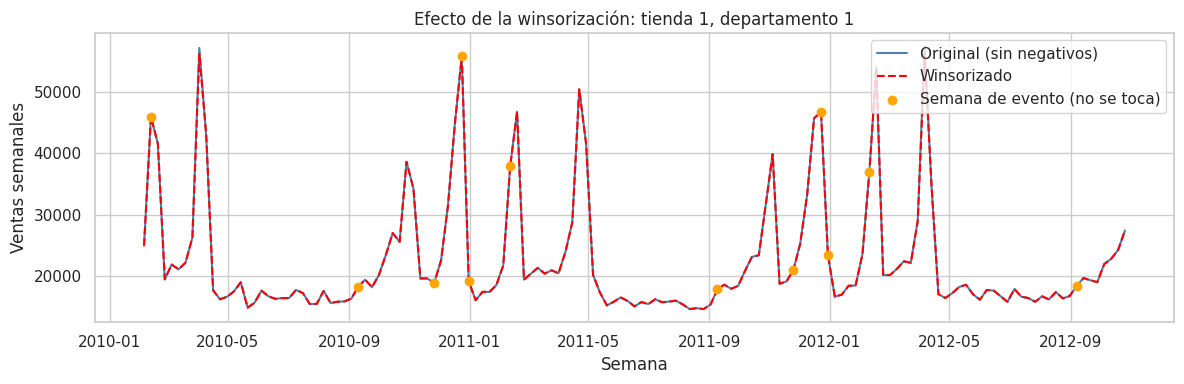

In [27]:
# Detección: z-score dentro de cada serie tienda-departamento (mismo método de la práctica de outliers)
grupo = df_modelo.groupby(["Store", "Dept"])["Ventas_Modelo"]
df_modelo["Z_Score"] = ((df_modelo["Ventas_Modelo"] - grupo.transform("mean")) / grupo.transform("std")).replace([np.inf, -np.inf], np.nan)
df_modelo["Outlier_Z"] = df_modelo["Z_Score"].abs() > 3

# Tratamiento: winsorización superior (percentil 99 de la serie) solo en semanas SIN evento
p99_serie = (df_modelo[~df_modelo["Es_Evento"]]
             .groupby(["Store", "Dept"])["Ventas_Modelo"].quantile(0.99)
             .rename("P99_Sin_Evento").reset_index())
df_modelo = df_modelo.merge(p99_serie, on=["Store", "Dept"], how="left")

aplicar_tope = (~df_modelo["Es_Evento"]) & df_modelo["P99_Sin_Evento"].notna()
df_modelo["Ventas_Winsor"] = np.where(aplicar_tope,
                                      np.minimum(df_modelo["Ventas_Modelo"], df_modelo["P99_Sin_Evento"]),
                                      df_modelo["Ventas_Modelo"])

modificadas = int((df_modelo["Ventas_Winsor"] != df_modelo["Ventas_Modelo"]).sum())
print(f"Outliers detectados (z > 3): {int(df_modelo['Outlier_Z'].sum()):,}")
print(f"   de los cuales en semanas de evento (se conservan): {int((df_modelo['Outlier_Z'] & df_modelo['Es_Evento']).sum()):,}")
print(f"Valores modificados por la winsorización: {modificadas:,} ({modificadas / len(df_modelo):.2%})")

# Figura 6: efecto de la winsorización en la serie con más valores modificados
combo_top = (df_modelo[df_modelo["Ventas_Winsor"] != df_modelo["Ventas_Modelo"]]
             .groupby(["Store", "Dept"]).size().idxmax())
serie = df_modelo[(df_modelo["Store"] == combo_top[0]) & (df_modelo["Dept"] == combo_top[1])].sort_values("Date")

plt.figure(figsize=(12, 4))
plt.plot(serie["Date"], serie["Ventas_Modelo"], color="steelblue", label="Original (sin negativos)")
plt.plot(serie["Date"], serie["Ventas_Winsor"], color="red", linestyle="--", label="Winsorizado")
plt.scatter(serie.loc[serie["Es_Evento"], "Date"], serie.loc[serie["Es_Evento"], "Ventas_Winsor"], color="orange", zorder=5, label="Semana de evento (no se toca)")
plt.title(f"Efecto de la winsorización: tienda {combo_top[0]}, departamento {combo_top[1]}")
plt.xlabel("Semana")
plt.ylabel("Ventas semanales")
plt.legend(loc="upper right")
plt.tight_layout()
guardar_figura("fig6_winsorizacion.png")
plt.show()

## **4.8 Variables derivadas: rezagos y promedio móvil**
Los rezagos (*lags*) son las ventas de semanas anteriores de la misma tienda y departamento. Se calculan **buscando la fecha exacta** (fecha + k semanas), así que si una semana no existe el rezago queda nulo y no se inventa un valor.
- `Ventas_t_menos_1`: ventas de la semana anterior.
- `Ventas_t_menos_52`: ventas de la misma semana un año antes (captura la estacionalidad).
- `Media_Movil_4`: promedio de las 4 semanas anteriores.

In [28]:
# Función: agrega el rezago de k semanas buscando la fecha exacta (fecha + k semanas)
def agregar_rezago(df, k):
    aux = df[["Store", "Dept", "Date", "Ventas_Winsor"]].copy()
    aux["Date"] = aux["Date"] + pd.Timedelta(weeks=k)
    aux = aux.rename(columns={"Ventas_Winsor": f"Ventas_t_menos_{k}"})
    return df.merge(aux, on=["Store", "Dept", "Date"], how="left")

for k in [1, 2, 3, 4, 52]:
    df_modelo = agregar_rezago(df_modelo, k)

# Promedio móvil de las 4 semanas anteriores (usa solo las semanas que existen)
df_modelo["Media_Movil_4"] = df_modelo[["Ventas_t_menos_1", "Ventas_t_menos_2", "Ventas_t_menos_3", "Ventas_t_menos_4"]].mean(axis=1)
df_modelo = df_modelo.drop(columns=["Ventas_t_menos_2", "Ventas_t_menos_3", "Ventas_t_menos_4"])

# Variables de calendario
df_modelo["Anio"] = df_modelo["Date"].dt.year
df_modelo["Mes"] = df_modelo["Date"].dt.month
df_modelo["Semana_Anio"] = df_modelo["Date"].dt.isocalendar().week.astype(int)

# Interacción: efecto de los descuentos en semanas de evento
df_modelo["MarkDown_x_Evento"] = df_modelo["Total_MarkDown"] * df_modelo["Es_Evento"].astype(int)

print("Nulos en rezagos (esperados en las primeras semanas de cada serie y en los huecos):")
print(df_modelo[["Ventas_t_menos_1", "Ventas_t_menos_52", "Media_Movil_4"]].isnull().sum())

Nulos en rezagos (esperados en las primeras semanas de cada serie y en los huecos):
Ventas_t_menos_1       6200
Ventas_t_menos_52    155541
Media_Movil_4          3579
dtype: int64


In [29]:
#Bandera de temorada alta

df_modelo["Es_Diciembre"] = (df_modelo["Mes"] == 12).astype(int)
df_modelo["Es_Temporada_Alta"] = df_modelo["Mes"].isin([11, 12]).astype(int)  # nov-dic
df_modelo["Trimestre"] = df_modelo["Date"].dt.quarter                          # 1 a 4
df_modelo["Semana_Del_Mes"] = (df_modelo["Date"].dt.day - 1) // 7 + 1          # 1 a 5

print("### Banderas de temporada ###")
print("Filas en diciembre:", int(df_modelo["Es_Diciembre"].sum()),
      f"({df_modelo['Es_Diciembre'].mean():.1%})")
print("Filas en temporada alta (nov-dic):", int(df_modelo["Es_Temporada_Alta"].sum()),
      f"({df_modelo['Es_Temporada_Alta'].mean():.1%})")
print("\nDistribución por trimestre:")
print(df_modelo["Trimestre"].value_counts().sort_index())

# Comprobación de que las banderas capturan el pico: ventas promedio por temporada
print("\nVenta promedio según temporada alta:")
print(df_modelo.groupby("Es_Temporada_Alta")["Ventas_Winsor"].mean().round(0))

### Banderas de temporada ###
Filas en diciembre: 29337 (7.0%)
Filas en temporada alta (nov-dic): 52727 (12.7%)

Distribución por trimestre:
Trimestre
1     96319
2    113479
3    116081
4     90736
Name: count, dtype: int64

Venta promedio según temporada alta:
Es_Temporada_Alta
0    15782.0
1    18683.0
Name: Ventas_Winsor, dtype: float64


## **4.9 Normalización y codificación**
- **Ventas por tamaño de tienda** (`Ventas_por_1000_Size`): hace comparables tiendas grandes y pequeñas.
- **Transformación logarítmica** (`Log_Ventas`): reduce la asimetría de las ventas.
- **Temperatura a grados Celsius** y **estandarización (z-score)** de las variables externas.
- **Codificación One-Hot** del tipo de tienda (A, B, C).

*Nota:* aquí el `StandardScaler` se ajusta con todos los datos solo para dejar el dataset listo. Cuando se entrene el modelo debe ajustarse únicamente con los datos de entrenamiento.

Asimetría de Weekly_Sales original: 3.26
Asimetría de Log_Ventas: -1.23

Media y desviación de las variables estandarizadas:
      Temperatura_C_z  Fuel_Price_z  CPI_z  Unemployment_z
mean              0.0          -0.0    0.0            -0.0
std               1.0           1.0    1.0             1.0


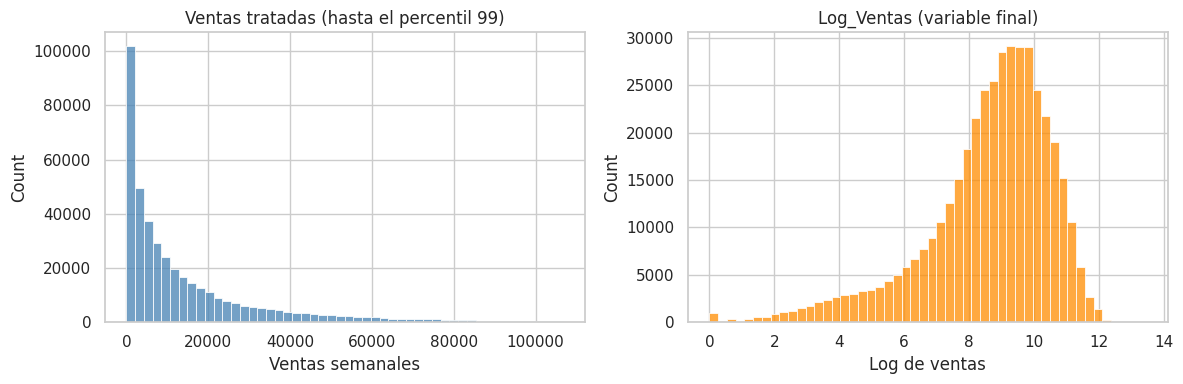

In [30]:
# Ventas por tamaño de tienda y transformación logarítmica
df_modelo["Ventas_por_1000_Size"] = df_modelo["Ventas_Winsor"] / df_modelo["Size"] * 1000
df_modelo["Log_Ventas"] = np.log1p(df_modelo["Ventas_Winsor"])

# Temperatura de Fahrenheit a Celsius
df_modelo["Temperatura_C"] = (df_modelo["Temperature"] - 32) * 5 / 9

# Estandarización (z-score) de las variables externas
cols_escalar = ["Temperatura_C", "Fuel_Price", "CPI", "Unemployment"]
escalador = StandardScaler()
escaladas = escalador.fit_transform(df_modelo[cols_escalar])
for i, col in enumerate(cols_escalar):
    df_modelo[col + "_z"] = escaladas[:, i]

# Codificación One-Hot del tipo de tienda
df_modelo = pd.concat([df_modelo, pd.get_dummies(df_modelo["Type"], prefix="Tipo", dtype=int)], axis=1)

# Comparación de la asimetría antes y después
print("Asimetría de Weekly_Sales original:", round(df_ventas["Weekly_Sales"].skew(), 2))
print("Asimetría de Log_Ventas:", round(df_modelo["Log_Ventas"].skew(), 2))
print("\nMedia y desviación de las variables estandarizadas:")
print(df_modelo[[c + "_z" for c in cols_escalar]].agg(["mean", "std"]).round(2))

# Figura 7: antes y después (original vs logarítmica del dataset final)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_modelo.loc[df_modelo["Ventas_Winsor"] <= df_modelo["Ventas_Winsor"].quantile(0.99), "Ventas_Winsor"], bins=50, ax=axes[0], color="steelblue")
axes[0].set_title("Ventas tratadas (hasta el percentil 99)")
axes[0].set_xlabel("Ventas semanales")
sns.histplot(df_modelo["Log_Ventas"], bins=50, ax=axes[1], color="darkorange")
axes[1].set_title("Log_Ventas (variable final)")
axes[1].set_xlabel("Log de ventas")
plt.tight_layout()
guardar_figura("fig7_antes_despues.png")
plt.show()

## **4.10 Verificación y guardado del dataset final**
Antes de guardar se revisan los nulos que quedan y se comprime el archivo en `.csv.gz` para que sea liviano al subirlo al repositorio de GitHub.

> **Carga (L del ETL).** La celda siguiente verifica y guarda el dataset final integrado en `ventas_integrado_limpio.csv.gz`. La transformación (T) corresponde a la sección 4 completa.

In [31]:
# Verificación final del dataset
print("Dimensiones del dataset final:", df_modelo.shape)
print("Rango de fechas:", df_modelo["Date"].min().date(), "a", df_modelo["Date"].max().date())
print("Duplicados (Store, Dept, Date):", int(df_modelo.duplicated(["Store", "Dept", "Date"]).sum()))

nulos_final = df_modelo.isnull().sum()
print("\nColumnas con nulos (solo los rezagos deben tener nulos):")
print(nulos_final[nulos_final > 0])

# Ordenar y guardar comprimido
df_modelo = df_modelo.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)
ruta_salida = ruta_base + "ventas_integrado_limpio.csv.gz"
df_modelo.to_csv(ruta_salida, index=False, compression="gzip")
print(f"\nDataset final guardado en: {ruta_salida}")
print(f"Tamaño del archivo: {os.path.getsize(ruta_salida) / 1e6:.1f} MB")

Dimensiones del dataset final: (416615, 57)
Rango de fechas: 2010-02-05 a 2012-10-26
Duplicados (Store, Dept, Date): 0

Columnas con nulos (solo los rezagos deben tener nulos):
Ventas_t_menos_1       6200
Ventas_t_menos_52    155541
Media_Movil_4          3579
dtype: int64

Dataset final guardado en: /content/drive/My Drive/Maestria/ETL/Entrega_2/figuras/ventas_integrado_limpio.csv.gz
Tamaño del archivo: 52.3 MB


---
# **5. Coherencia y Trazabilidad**

Esta tabla conecta cada **hallazgo** del EDA y de la calidad con su **impacto** sobre el problema y con la **transformación** que se aplicó. Es la cadena **hallazgo → problema → transformación** que pide la rúbrica. Los números se calculan con los resultados de las secciones anteriores.

In [32]:
trazabilidad = pd.DataFrame({
    "Hallazgo (EDA / Calidad)": [
        f"{pct_md_sin_dato:.0%} de las filas sin descuentos; datos de MarkDown solo desde {fecha_inicio_md.date()}",
        f"{md_negativos} descuentos negativos",
        f"{n_negativas} ventas negativas y {n_ceros} ceros",
        f"{filas_faltantes:,} filas faltantes ({huecos_internos:,} huecos internos)",
        f"{combos_cortos} series con menos de 52 semanas",
        f"Semana pico de Navidad sin marcar en IsHoliday ({ventas_pico:.1f} M vs {ventas_marcada:.1f} M)",
        f"{n_z3:,} extremos (z > 3); {pct_extremos_evento:.0%} en semanas de evento",
        f"Asimetría de las ventas = {df_ventas['Weekly_Sales'].skew():.1f}",
        f"Tiendas A/B/C con tamaños distintos (correlación tamaño-ventas = {corr_size:.2f})",
        "Temperatura en Fahrenheit; variables externas en escalas distintas",
        "Features llega a 2013 pero las ventas terminan en oct. 2012",
        "Tres archivos con granularidades distintas + fuente externa JSON"
    ],
    "Impacto sobre el problema": [
        "Imputar con la media inventaría promociones inexistentes",
        "Valores inválidos para un descuento",
        "El logaritmo no se puede calcular y se distorsionan los errores",
        "Rompe los rezagos y promedios móviles",
        "No muestran un ciclo anual completo para aprender estacionalidad",
        "El modelo no aprende el efecto real de Navidad",
        "Eliminarlos borraría justo los eventos que se quiere predecir",
        "Pocos valores enormes dominan el error del modelo",
        "Ventas no comparables entre tiendas",
        "Escalas incompatibles entre variables",
        "Semanas sin ventas ni objetivo para entrenar",
        "No se pueden cruzar directamente"
    ],
    "Transformación asociada": [
        "Nulo = 0 + bandera MD_Registrado (secciones 4.3)",
        "Llevar negativos a 0 (4.3)",
        "Bandera Es_Devolucion + Ventas_Modelo (4.5)",
        "No rellenar la venta; rezagos por fecha exacta (4.8)",
        "Excluir series cortas (4.6)",
        "Calendario externo JSON anidado: Dias_a_Navidad, Sem_Pre_Navidad, Es_Evento (4.1)",
        "Winsorización P99 solo en semanas sin evento + bandera Outlier_Z (4.7)",
        "Transformación logarítmica Log_Ventas (4.9)",
        "Ventas_por_1000_Size y One-Hot del tipo de tienda (4.9)",
        "Conversión a Celsius y z-score (4.9)",
        "Recorte de Features al periodo con ventas (4.2)",
        "Integración en esquema en estrella (4.4)"
    ],
    "V afectada": [
        "Veracity", "Veracity", "Veracity", "Veracity", "Volume", "Veracity",
        "Variability", "Variability", "Variability", "Variety", "Volume", "Variety"
    ]
})

pd.set_option('display.max_colwidth', 90)
print("### Tabla de trazabilidad: hallazgo -> impacto -> transformación ###")
print(trazabilidad.to_string(index=False))

trazabilidad.to_csv(ruta_base + "trazabilidad.csv", index=False)
print("\nTabla guardada en:", ruta_base + "trazabilidad.csv")

### Tabla de trazabilidad: hallazgo -> impacto -> transformación ###
                                                Hallazgo (EDA / Calidad)                                        Impacto sobre el problema                                                           Transformación asociada  V afectada
64% de las filas sin descuentos; datos de MarkDown solo desde 2011-11-11         Imputar con la media inventaría promociones inexistentes                                  Nulo = 0 + bandera MD_Registrado (secciones 4.3)    Veracity
                                                 44 descuentos negativos                              Valores inválidos para un descuento                                                        Llevar negativos a 0 (4.3)    Veracity
                                        1285 ventas negativas y 73 ceros  El logaritmo no se puede calcular y se distorsionan los errores                                       Bandera Es_Devolucion + Ventas_Modelo (4.5)    Veracity
   

---
## **Resumen del proceso**
| Etapa | Qué se hizo | Resultado |
|---|---|---|
| EDA | Estructura, distribuciones, patrones temporales, relaciones | Figuras 1 a 4 |
| Calidad | Nulos, negativos, faltantes, festivos, tabla de las V's | Figura 5 y diagnóstico |
| Impacto | Medición del efecto de cada problema en el objetivo | Tabla de impacto |
| Transformaciones | Integración, limpieza, outliers, variables derivadas, normalización | Dataset `ventas_integrado_limpio.csv.gz` (figuras 6 y 7) |
| Trazabilidad | Cadena hallazgo → problema → transformación | `trazabilidad.csv` |

##Corrección: isHolliday

isHoliday se corrige: las semana de navidad no esta siendo contada como festivo, se cuenta la semana siguiente, lo que provoca que esta no sea incliuia en las demanda de festividad mas importante de EE.UU.

In [33]:


# Verificación de la marca corregida de festivos
orig = df_modelo.groupby("Date")["IsHoliday"].first().astype(bool)
nuev = df_modelo.groupby("Date")["IsHoliday_Corregido"].first().astype(bool)
ventas_sem = df_modelo.groupby("Date")["Ventas_Modelo"].sum()

print("Semanas marcadas — original :", int(orig.sum()))
print("Semanas marcadas — corregida:", int(nuev.sum()))
print("Intersección (debe ser 10)  :", int((orig & nuev).sum()))
print("Originales que se pierden   :", int((orig & ~nuev).sum()), "(debe ser 0)")

top4 = ventas_sem.nlargest(4).index
print("Top-4 semanas marcadas      :", int(nuev.loc[top4].sum()), "de 4")

print("\nVenta promedio por fila:")
for col in ["IsHoliday", "IsHoliday_Corregido"]:
    g = df_modelo.groupby(df_modelo[col].astype(bool))["Ventas_Modelo"].mean()
    print(f"  {col:22s}  no: {g[False]:>9,.0f}   sí: {g[True]:>9,.0f}   brecha: {g[True]-g[False]:>8,.0f}")

Semanas marcadas — original : 10
Semanas marcadas — corregida: 12
Intersección (debe ser 10)  : 10
Originales que se pierden   : 0 (debe ser 0)
Top-4 semanas marcadas      : 4 de 4

Venta promedio por fila:
  IsHoliday               no:    16,086   sí:    17,280   brecha:    1,194
  IsHoliday_Corregido     no:    15,920   sí:    18,884   brecha:    2,963


La marca corregida conserva las diez semanas que la bandera original ya identificaba y añade las dos semanas previas a Navidad, donde está el pico real de compra. Con ello, las cuatro semanas de mayor venta del periodo quedan marcadas, frente a dos de cuatro con la bandera original, y la diferencia de venta promedio entre semanas marcadas y no marcadas pasa de 1.194 a 2.963 por registro.

##Modelo 1: Regresión Lineal

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

df_m = df_modelo.copy()

quitamos filas sin rezago de 1 semana

In [35]:
antes = len(df_m)
df_m = df_m.dropna(subset=["Ventas_t_menos_1", "Media_Movil_4"]).reset_index(drop=True)
print(f"Filas antes: {antes:,} | Filas sin pasado: {len(df_m):,}")

Filas antes: 416,615 | Filas sin pasado: 410,415


El rezago de 1 año (t-52) tiene muchos nulos
No se borran esas filas, se rellenan hueco con 0 y dejamos una bandera para que el modelo sepa que no había dato

In [36]:
df_m["Tiene_t52"] = df_m["Ventas_t_menos_52"].notna().astype(int)
df_m["Ventas_t_menos_52"] = df_m["Ventas_t_menos_52"].fillna(0)

print("Nulos restantes en columnas clave:",
      int(df_m[["Ventas_t_menos_1","Media_Movil_4","Ventas_t_menos_52"]].isnull().sum().sum()))

Nulos restantes en columnas clave: 0


Separacion de datos: separa los datos en dos, modelo aprende con el pasado (train) y lo examinamos con las últimas semanas, que él nunca vio (test)

In [37]:
fecha_corte = "2012-08-01"

train = df_m[df_m["Date"] < fecha_corte].copy()
test  = df_m[df_m["Date"] >= fecha_corte].copy()

print(f"Entrenamiento (train): {len(train):,} filas | hasta {train['Date'].max().date()}")
print(f"Prueba (test):        {len(test):,} filas | desde {test['Date'].min().date()} hasta {test['Date'].max().date()}")
print(f"Proporción test: {len(test)/len(df_m):.1%}")

Entrenamiento (train): 372,803 filas | hasta 2012-07-27
Prueba (test):        37,612 filas | desde 2012-08-03 hasta 2012-10-26
Proporción test: 9.2%


Seleccion de columnas que ingresan al modelo:

In [38]:
objetivo = "Log_Ventas"

#columnas que no  se usaran
fuga = ["Weekly_Sales", "Ventas_Modelo", "Ventas_Winsor", "Ventas_por_1000_Size",
        "Log_Ventas", "Temperature", "Temperatura_C"]  # las _z ya reemplazan a estas
ids  = ["Store", "Dept", "Date", "Type"]

#features: columnas numericas que si se implementa en RL
numericas = df_m.select_dtypes(include=["number", "bool"]).columns.tolist()
features = [c for c in numericas if c not in fuga and c not in ids]

print(f"Total de features: {len(features)}")
print(features)

Total de features: 47
['IsHoliday', 'Size', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'MD_Registrado', 'Total_MarkDown', 'Sem_Pre_Navidad', 'Contiene_Evento', 'IsHoliday_Corregido', 'Dias_a_Navidad', 'Dias_a_AccionGracias', 'Dias_a_LaborDay', 'Dias_a_SuperBowl', 'Dias_desde_Navidad', 'Dias_desde_AccionGracias', 'Dias_desde_LaborDay', 'Dias_desde_SuperBowl', 'Es_Evento', 'Es_Devolucion', 'Z_Score', 'Outlier_Z', 'P99_Sin_Evento', 'Ventas_t_menos_1', 'Ventas_t_menos_52', 'Media_Movil_4', 'Anio', 'Mes', 'Semana_Anio', 'MarkDown_x_Evento', 'Es_Diciembre', 'Es_Temporada_Alta', 'Trimestre', 'Semana_Del_Mes', 'Temperatura_C_z', 'Fuel_Price_z', 'CPI_z', 'Unemployment_z', 'Tipo_A', 'Tipo_B', 'Tipo_C', 'Tiene_t52']


In [39]:
# Los rezagos entran en logaritmo, igual que el objetivo
rezagos = ["Ventas_t_menos_1", "Ventas_t_menos_52", "Media_Movil_4"]
train = train.copy()
test  = test.copy()
for c in rezagos:
    train["log_" + c] = np.log1p(train[c].clip(lower=0))
    test["log_" + c]  = np.log1p(test[c].clip(lower=0))

features = [("log_" + c if c in rezagos else c) for c in features]

In [40]:
# El modelo usa las columnas CRUDAS; el escalado va DESPUÉS del corte temporal
quitar = ["Z_Score", "Outlier_Z", "Es_Devolucion", "P99_Sin_Evento", "IsHoliday"]
quitar += [c for c in features if c.endswith("_z")]
features = [c for c in features if c not in quitar]

# devolvemos las versiones sin escalar de las variables externas
for c in ["Temperatura_C", "Fuel_Price", "CPI", "Unemployment"]:
    if c not in features:
        features.append(c)

X_train_crudo = train[features]
X_test_crudo  = test[features]
y_train = train[objetivo]
y_test  = test[objetivo]

# El escalador aprende SOLO del pasado y se aplica al futuro
escalador_modelo = StandardScaler().fit(X_train_crudo)
X_train = pd.DataFrame(escalador_modelo.transform(X_train_crudo),
                       columns=features, index=X_train_crudo.index)
X_test  = pd.DataFrame(escalador_modelo.transform(X_test_crudo),
                       columns=features, index=X_test_crudo.index)

print(f"Features: {len(features)}")
print(f"X_train {X_train.shape} | X_test {X_test.shape}")
print("Columnas _z restantes:", sum(c.endswith('_z') for c in features), "(debe ser 0)")
print("Media de X_train:", round(X_train.mean().mean(), 6), "(debe ser ~0)")

Features: 39
X_train (372803, 39) | X_test (37612, 39)
Columnas _z restantes: 0 (debe ser 0)
Media de X_train: 0.0 (debe ser ~0)


In [41]:
print("media de X_train al entrenar el baseline:", round(X_train.mean().mean(), 6))

media de X_train al entrenar el baseline: 0.0


Modelo de regresion lineal

In [42]:
# El baseline se entrena aquí mismo, para que no pueda quedar antes del escalado
baseline = LinearRegression().fit(X_train, y_train)
pred_base = baseline.predict(X_test)
print("Predicción máx en log:", round(pred_base.max(), 2), "(debe ser < 14)")

Predicción máx en log: 12.28 (debe ser < 14)


In [43]:
print("Baseline regresión lineal entrenado.")
print("5 predicciones en escala log:", pred_base[:5].round(3))


Baseline regresión lineal entrenado.
5 predicciones en escala log: [9.762 9.732 9.676 9.718 9.727]


## Modelo2: XG-Boost

In [44]:
from xgboost import XGBRegressor
modelo = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
modelo.fit(X_train, y_train)

# Prediccion
pred_xgb = modelo.predict(X_test)

print("XGBoost entrenado.")
print("5 predicciones en escala log:", pred_xgb[:5].round(3))

XGBoost entrenado.
5 predicciones en escala log: [9.684 9.677 9.663 9.703 9.644]


##Metricas

In [45]:
# Devolvo de escala de log a reales
real  = np.expm1(y_test)
base  = np.expm1(pred_base)
xgb   = np.expm1(pred_xgb)

def evaluar(nombre, real, pred):
    mae  = mean_absolute_error(real, pred)
    rmse = mean_squared_error(real, pred) ** 0.5
    print(f"{nombre:20s} | MAE: {mae:,.0f} | RMSE: {rmse:,.0f}")

In [46]:
print("Error:\n")
evaluar("Baseline (lineal)", real, base)
evaluar("XGBoost", real, xgb)

Error:

Baseline (lineal)    | MAE: 1,555 | RMSE: 3,385
XGBoost              | MAE: 1,292 | RMSE: 2,708


In [47]:
print(f"\nVenta promedio real: {real.mean():,.0f}")
print(f"Venta mediana real:  {real.median():,.0f}")


Venta promedio real: 15,989
Venta mediana real:  7,780


El primer intento de modelo lineal reportó un MAE de 93.801. El error no provenía del modelo sino de la coherencia de escalas: la variable objetivo está en logaritmo y los rezagos entraban en pesos, de modo que la relación entre ambos es curva y la recta extrapolaba hasta predicciones de 58 millones. Con los rezagos transformados a logaritmo, el modelo lineal alcanza un MAE de 1.555 y el XGBoost de 1.292: una mejora del 17 % que justifica el modelo de árboles sin descalificar al lineal.

El RMSE del XGBoost (2.771) es como el doble del MAE, lo que indica que falla un poco en algunas semanas puntuales

Top 10 variables más importantes:
log_Ventas_t_menos_1     0.698
log_Media_Movil_4        0.095
Anio                     0.073
Mes                      0.044
log_Ventas_t_menos_52    0.011
Tipo_C                   0.008
Dias_desde_Navidad       0.007
Dias_a_Navidad           0.004
IsHoliday_Corregido      0.004
Dias_a_SuperBowl         0.004
Sem_Pre_Navidad          0.003
Dias_a_LaborDay          0.003
Tipo_B                   0.003
Dias_desde_LaborDay      0.003
MD_Registrado            0.003
dtype: float32


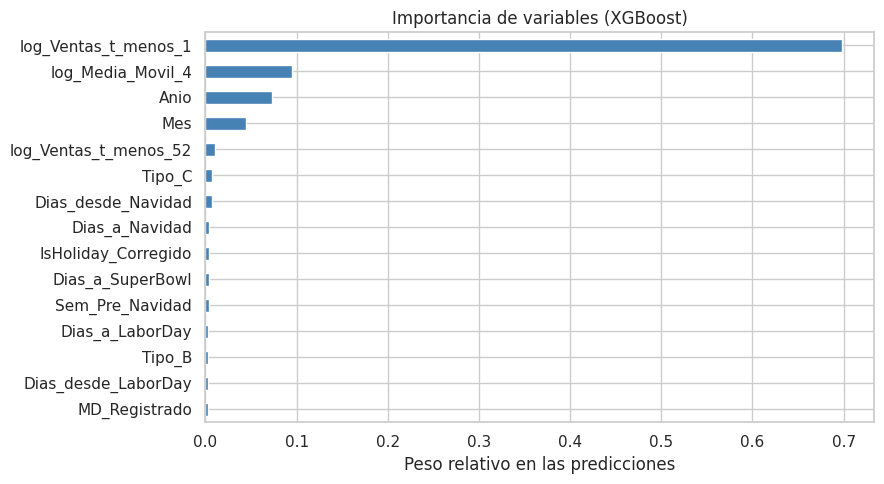

In [48]:
#Variables significativas en XG Boost
importancia = pd.Series(modelo.feature_importances_, index=features).sort_values(ascending=False)

print("Top 10 variables más importantes:")
print(importancia.head(15).round(3))

plt.figure(figsize=(9, 5))
importancia.head(15).sort_values().plot(kind="barh", color="steelblue")
plt.title("Importancia de variables (XGBoost)")
plt.xlabel("Peso relativo en las predicciones")
plt.tight_layout()
guardar_figura("fig9_importancia.png")
plt.show()

Lo mas significativo para predecir la venta de la siguiente semana son las ventas de la semana anterior ventas_t_menos_1
